#F1 Classic Era Data Analysis (1950–2012)
Author: Javier Cejuela

This project analyzes Formula 1 data from the classic era (1950–2012), before the introduction of KERS and DRS, which radically changed the sport.

Through five visualizations, we will answer key questions about the historical dominant teams, the evolution of the top drivers, and the factors that influence the results.

Data sources:
Kaggle — Formula 1 World Championship dataset (CSV)
Jolpica API — Official API for historical F1 statistics



In [17]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [18]:
#import os

#ruta = '/content/drive/MyDrive/Proyecto Data/'
#os.listdir(ruta)
base_url = 'https://raw.githubusercontent.com/cceju/Data-Visualization-Proyect/main/'

result = pd.read_csv(base_url + 'results.csv')
resultRaces = pd.read_csv(base_url + 'races.csv')
resultDrivers = pd.read_csv(base_url + 'drivers.csv')
resultConstructors = pd.read_csv(base_url + 'constructors.csv')
resultPitStop = pd.read_csv(base_url + 'pit_stops.csv')
resultQualy = pd.read_csv(base_url + 'qualifying.csv')

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px  # el alias típico es "px"
import pandas as pd        # el alias típico es "pd"

In [20]:
base_url = 'https://raw.githubusercontent.com/cceju/Data-Visualization-Proyect/main/'

result = pd.read_csv(base_url + 'results.csv')
resultRaces = pd.read_csv(base_url + 'races.csv')
resultDrivers = pd.read_csv(base_url + 'drivers.csv')
resultConstructors = pd.read_csv(base_url + 'constructors.csv')
resultPitStop = pd.read_csv(base_url + 'pit_stops.csv')
resultQualy = pd.read_csv(base_url + 'qualifying.csv')

In [21]:
resultRaces = pd.read_csv(ruta + 'races.csv')
resultRaces.head()


NameError: name 'ruta' is not defined

In [ ]:
resultDrivers = pd.read_csv(ruta + 'drivers.csv')
resultDrivers.head()

In [ ]:
resultConstructors = pd.read_csv(ruta + 'constructors.csv')
resultConstructors.head()

In [ ]:
resultPitStop = pd.read_csv(ruta + 'pit_stops.csv')
resultPitStop.head()

In [ ]:
resultQualy = pd.read_csv(ruta + 'qualifying.csv')
resultQualy.head()

In [22]:
print(result)
print(resultRaces)
print(resultDrivers)
print(resultConstructors)
print(resultPitStop)
print(resultQualy)

       resultId  raceId  driverId  constructorId number  grid position  \
0             1      18         1              1     22     1        1   
1             2      18         2              2      3     5        2   
2             3      18         3              3      7     7        3   
3             4      18         4              4      5    11        4   
4             5      18         5              1     23     3        5   
...         ...     ...       ...            ...    ...   ...      ...   
26754     26760    1144       825            210     20    14       16   
26755     26761    1144       859            215     30    12       17   
26756     26762    1144       822             15     77     9       \N   
26757     26763    1144       861              3     43    20       \N   
26758     26764    1144       815              9     11    10       \N   

      positionText  positionOrder  points  laps         time milliseconds  \
0                1              1 

In [23]:
print(type(resultRaces))

<class 'pandas.core.frame.DataFrame'>


In [24]:
df = resultRaces.copy()
races_classic = resultRaces[resultRaces['year'] <= 2012]
display(races_classic)

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873,875,2012,16,35,Korean Grand Prix,2012-10-14,06:00:00,http://en.wikipedia.org/wiki/2012_Korean_Grand...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
874,876,2012,17,68,Indian Grand Prix,2012-10-28,09:30:00,http://en.wikipedia.org/wiki/2012_Indian_Grand...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
875,877,2012,18,24,Abu Dhabi Grand Prix,2012-11-04,13:00:00,http://en.wikipedia.org/wiki/2012_Abu_Dhabi_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
876,878,2012,19,69,United States Grand Prix,2012-11-18,19:00:00,http://en.wikipedia.org/wiki/2012_United_State...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [25]:
raceIds_classic = races_classic['raceId'].tolist()
results_classic = result[result['raceId'].isin(raceIds_classic)]
qualifying_classic = resultQualy[resultQualy['raceId'].isin(raceIds_classic)]
pitstops_classic = resultPitStop[resultPitStop['raceId'].isin(raceIds_classic)]

In [26]:
print(results_classic.shape)
print(qualifying_classic.shape)
print(pitstops_classic.shape)

(21715, 18)
(5466, 9)
(2060, 7)


In [27]:
# Extraer raceIds de 1950-2009
raceIds_classic = races_classic['raceId'].tolist()

# Filtrar todos los dataframes
results_classic = result[result['raceId'].isin(raceIds_classic)]
qualifying_classic = resultQualy[resultQualy['raceId'].isin(raceIds_classic)]
pitstops_classic = resultPitStop[resultPitStop['raceId'].isin(raceIds_classic)]

## Question 1: Which teams dominated F1 between 1950 and 2012?

The classic era of F1 was marked by great dynasties of teams.
Ferrari, McLaren, and Williams vied for supremacy for decades.
But how dominant were they really in terms of victories?

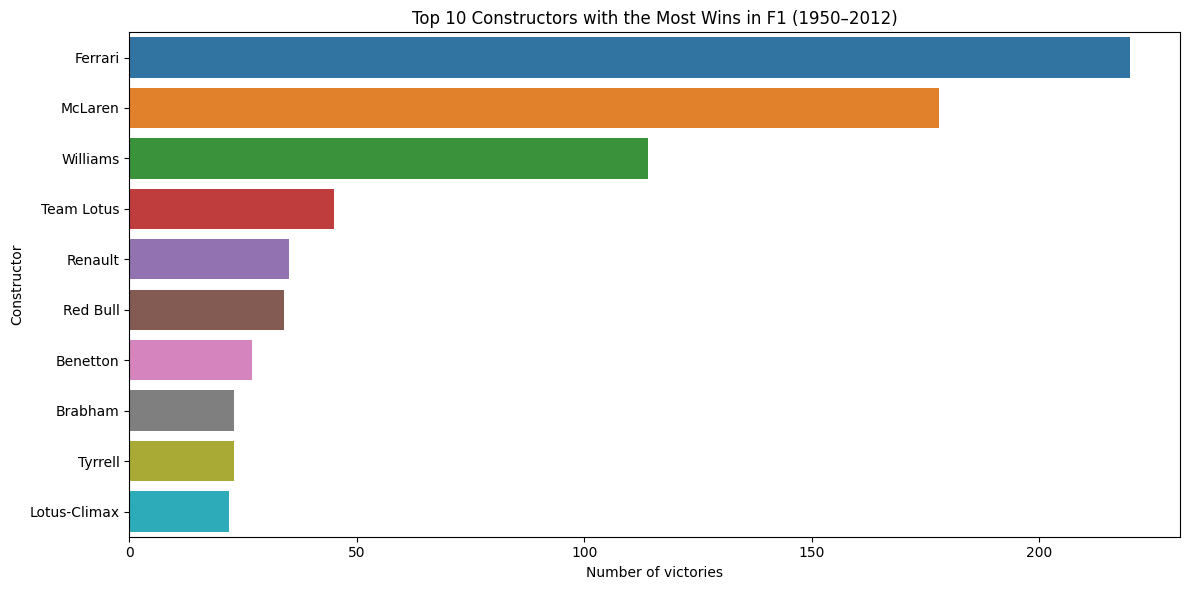

In [39]:
# Merge para obtener nombres de constructores
wins = results_classic[results_classic['positionOrder'] == 1]
win_counts = wins['constructorId'].value_counts().reset_index()
win_counts.columns = ['constructorId', 'wins']
win_counts = win_counts.merge(resultConstructors[['constructorId', 'name']], on='constructorId')


# Top 10
top10 = win_counts.head(10)

# Gráfica
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x='wins', y='name', palette='tab10')
plt.title('Top 10 Constructors with the Most Wins in F1 (1950–2012)')
plt.xlabel('Number of victories')
plt.ylabel('Constructor')
plt.tight_layout()
plt.show()

Ferrari holds a clear lead with more than 200 victories, followed by McLaren and Williams.
Their dominance reflects decades of investment and continuous technical development during the classic era.

In [29]:
resultDrivers[resultDrivers['surname'].isin(['Schumacher', 'Alonso', 'Senna'])]
results_classic[results_classic['driverId'] == 34].shape
print(races_classic['year'].max())
print(results_classic['raceId'].isin(races_classic['raceId']).sum())

2012
21715


In [30]:
resultDrivers[resultDrivers['surname'] == 'Alonso'][['driverId', 'forename', 'surname']].values

array([[4, 'Fernando', 'Alonso']], dtype=object)

## Q2: How did the performance of Schumacher, Senna, and Alonso evolve?
Points earned per season by the three greats of the classic era.

In [41]:
driver_ids = [4, 30, 102]
driver_results = results_classic[results_classic['driverId'].isin(driver_ids)].copy()

driver_results = driver_results.merge(races_classic[['raceId', 'year']], on='raceId')
driver_results = driver_results.merge(
    resultDrivers[['driverId', 'forename', 'surname']], on='driverId')

driver_results['full_name'] = driver_results['forename'] + ' ' + driver_results['surname']

driver_points = driver_results.groupby(['full_name', 'year'])['points'].sum().reset_index()

fig = px.line(driver_points, x='year', y='points', color='full_name',
              title='Points evolution per season (1950-2012)',
              labels={'year': 'Year', 'points': 'Points', 'full_name': 'Driver'})
fig.show()

Schumacher dominated from 2000 to 2004. Senna stood out for his consistency. Alonso ended the era on a high note.

In [32]:
pole_vs_result = qualifying_classic[['raceId', 'driverId', 'position']].merge(
    results_classic[['raceId', 'driverId', 'positionOrder']],
    on=['raceId', 'driverId']
)
pole_vs_result.head()

,raceId,driverId,position,positionOrder
0,18,1,1,1
1,18,9,2,9
2,18,5,3,5
3,18,13,4,13
4,18,2,5,2


## Q3: Does starting position affect the final race result?
Scatter plot with linear regression between qualifying position and final race position.

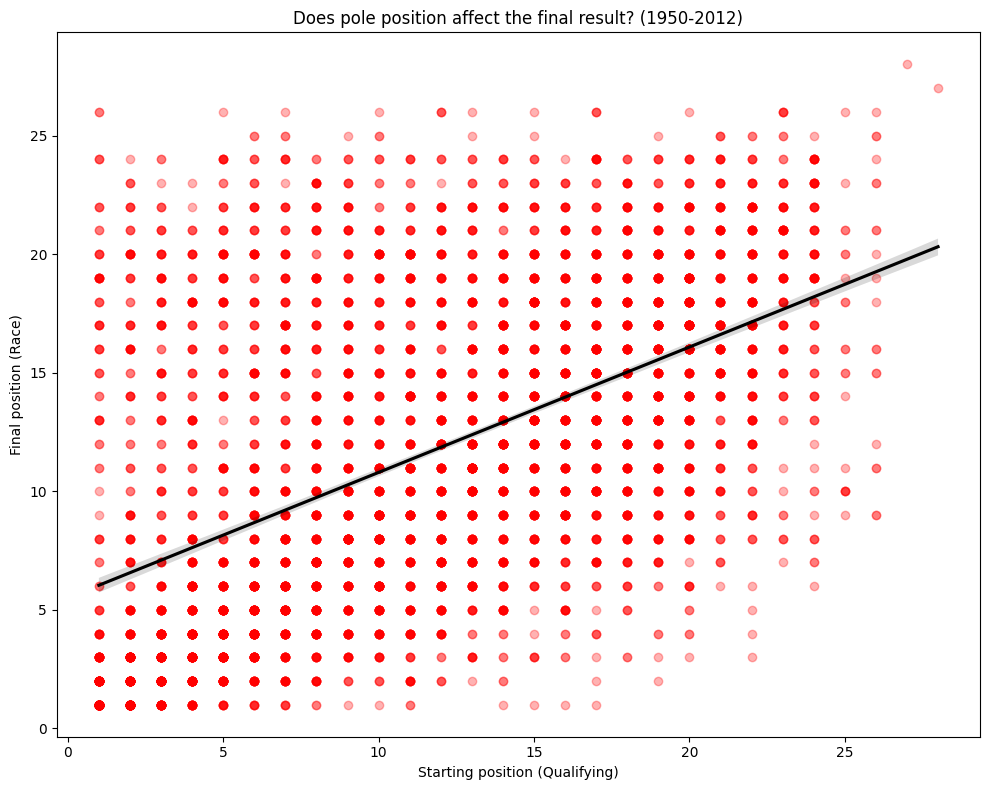

In [42]:
pole_vs_result = qualifying_classic[['raceId', 'driverId', 'position']].merge(
    results_classic[['raceId', 'driverId', 'positionOrder']],
    on=['raceId', 'driverId'])

plt.figure(figsize=(10, 8))
sns.regplot(data=pole_vs_result,
            x='position',
            y='positionOrder',
            scatter_kws={'alpha': 0.3, 'color': 'red'},
            line_kws={'color': 'black'})

plt.title('Does pole position affect the final result? (1950-2012)')
plt.xlabel('Starting position (Qualifying)')
plt.ylabel('Final position (Race)')
plt.tight_layout()
plt.show()

The correlation is clear: starting further up the grid significantly improves the chances of winning.

In [34]:
pitstops_classic.merge(races_classic[['raceId', 'name']], on='raceId').head()

,raceId,driverId,stop,lap,time,duration,milliseconds,name
0,841,153,1,1,17:05:23,26.898,26898,Australian Grand Prix
1,841,30,1,1,17:05:52,25.021,25021,Australian Grand Prix
2,841,17,1,11,17:20:48,23.426,23426,Australian Grand Prix
3,841,4,1,12,17:22:34,23.251,23251,Australian Grand Prix
4,841,13,1,13,17:24:10,23.842,23842,Australian Grand Prix


## Q4: Which circuits have the fastest pit stops?
Distribution of pit stop durations per circuit in seconds.

In [43]:
# Merge with circuit name
pitstops_merged = pitstops_classic.merge(
    races_classic[['raceId', 'name']], on='raceId')

# Clean null values and convert to seconds
pitstops_merged = pitstops_merged[pitstops_merged['milliseconds'] != '\\N']
pitstops_merged['seconds'] = pitstops_merged['milliseconds'].astype(float) / 1000

# Top 10 circuits with most data
top_circuits = pitstops_merged['name'].value_counts().head(10).index
pitstops_top = pitstops_merged[pitstops_merged['name'].isin(top_circuits)]

fig = px.box(pitstops_top,
             x='name',
             y='seconds',
             title='Pit stop duration by circuit (1950-2012)',
             labels={'name': 'Circuit', 'seconds': 'Duration (seconds)'},
             color='name')

fig.update_layout(xaxis_tickangle=-45, showlegend=False)
fig.show()

Spanish and German Grand Prix show the most consistent pit stop times, while Singapore records the slowest due to its street circuit layout.

## Q5: Which nationalities produced the most World Champions? (Source: Jolpica API)

For this visualization we use the **Jolpica API**, the official successor to the Ergast API,
which provides historical F1 statistics. We make one HTTP request per year (1950-2012)
to retrieve the World Champion and their nationality.

API endpoint used:
`https://api.jolpi.ca/ergast/f1/{year}/driverstandings/1.json`

No authentication is required — the API is free and publicly accessible.

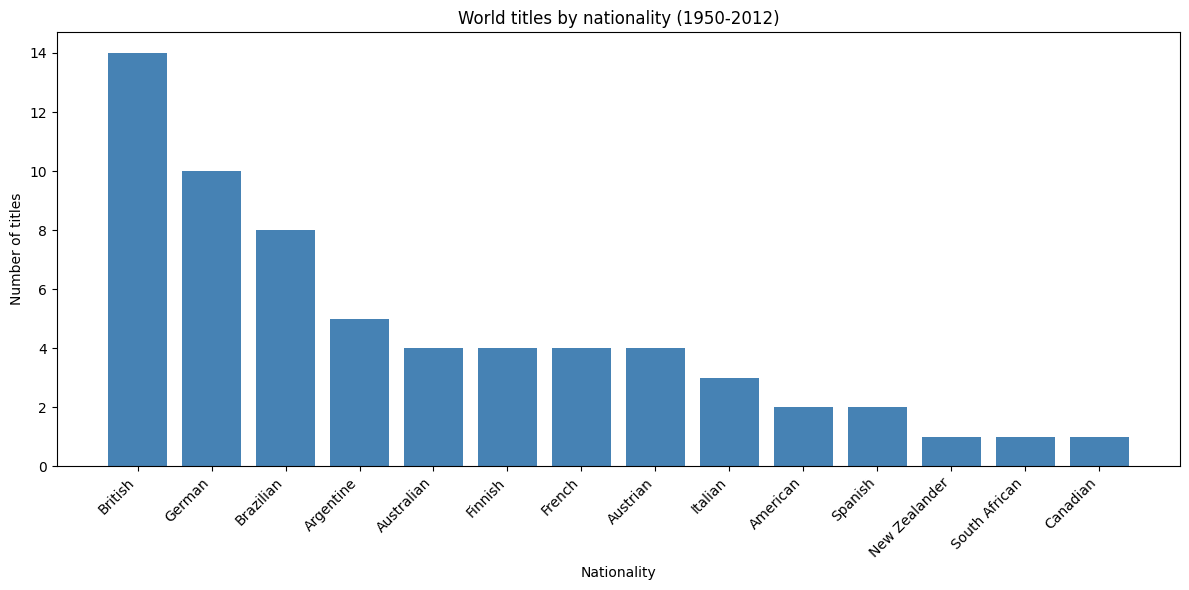

In [44]:
import requests

# Jolpica API call - champion per year
champions = []

for year in range(1950, 2013):
    url = f'https://api.jolpi.ca/ergast/f1/{year}/driverstandings/1.json'
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        try:
            standing = data['MRData']['StandingsTable']['StandingsLists'][0]['DriverStandings'][0]
            nationality = standing['Driver']['nationality']
            champions.append({'year': year, 'nationality': nationality})
        except:
            pass

# Convert to DataFrame
champions_df = pd.DataFrame(champions)

# Count by nationality
nationality_counts = champions_df['nationality'].value_counts().reset_index()
nationality_counts.columns = ['nationality', 'titles']

# Plot
plt.figure(figsize=(12, 6))
plt.bar(nationality_counts['nationality'],
        nationality_counts['titles'],
        color='steelblue')
plt.title('World titles by nationality (1950-2012)')
plt.xlabel('Nationality')
plt.ylabel('Number of titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
Great Britain leads with 14 titles, followed by Germany with 10 and Brazil with 8,
thanks to legends like Hammilton, Schummacher, Senna and Piquet.